# ChildSafeLens — Cyberbullying Detection Model (Hinglish + English)

**Pipeline:** data merge → EDA → preprocessing → feature engineering → classical ML benchmark (TF-IDF/BoW/Word2Vec/FastText + LinearSVC/LogReg/NB) → deep learning benchmark (RNN / LSTM / Bi-LSTM / CNN+BiLSTM) → final model selection → production artifact export.

This notebook focuses on benchmarking classical ML and deep learning models for cyberbullying detection on a newly merged, language-balanced dataset (75% Hinglish / 25% English).

In [1]:
from google.colab import files
uploaded = files.upload()

Saving ChildSafeLens_Final_Dataset (1).csv to ChildSafeLens_Final_Dataset (1) (1).csv


In [2]:
!pip install pandas numpy scikit-learn matplotlib nltk spacy gensim rapidfuzz pyspellchecker xgboost wordcloud tensorflow -q
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 100.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 116.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import re
import string
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

import spacy
nlp = spacy.load("en_core_web_sm", disable=["ner"])

from spellchecker import SpellChecker
from rapidfuzz import fuzz

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

from gensim.models import Word2Vec, FastText

from wordcloud import WordCloud

import joblib

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


## 1. Load & Merge the Source Datasets

We combine `ipd_merged_dataset.csv` and `hinglish_cyberbullying_dataset_10k_userwords.csv`, de-duplicate on normalized text, tag each row's language mix, and build a final corpus with 75% Hinglish and 25% English content.

In [5]:
import os

def _find(path):
    for p in [path, f"/content/{path}", f"./{path}"]:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(
        f"Could not find {path}. Upload it in the cell above or place it in the working directory."
    )

df_ipd = pd.read_csv(_find("ipd_merged_dataset.csv"))
df_hcb = pd.read_csv(_find("/content/hinglish_cyberbullying_dataset_10k_userwords (1).csv"))

print("ipd_merged_dataset.csv                          :", df_ipd.shape, list(df_ipd.columns))
print("hinglish_cyberbullying_dataset_10k_userwords.csv:", df_hcb.shape, list(df_hcb.columns))

ipd_merged_dataset.csv                          : (44148, 2) ['text', 'label']
hinglish_cyberbullying_dataset_10k_userwords.csv: (10000, 2) ['text', 'label']


In [6]:
# Standardise schema -> ['text', 'label'], label: -1 = bullying/harmful, 0 = non-bullying
df_ipd = df_ipd[["text", "label"]].copy()

df_hcb = df_hcb.rename(columns={"text": "text"})
df_hcb["label"] = df_hcb["label"].map({"cyberbullying": -1, "non-cyberbullying": 0})
df_hcb = df_hcb[["text", "label"]].copy()

assert df_hcb["label"].isnull().sum() == 0, "Unmapped label found while standardising hinglish_cb dataset"
print(df_hcb["label"].value_counts())

label
 0    5000
-1    5000
Name: count, dtype: int64


In [7]:
combined = pd.concat([df_ipd, df_hcb], ignore_index=True)
print("Rows before de-duplication:", combined.shape[0])

combined["text"] = combined["text"].astype(str).str.strip()
combined = combined[combined["text"] != ""]
combined["_text_key"] = combined["text"].str.lower()
combined = combined.drop_duplicates(subset="_text_key").drop(columns="_text_key").reset_index(drop=True)

print("Rows after de-duplication :", combined.shape[0])
print(combined["label"].value_counts())
# NOTE: the big drop here is expected and healthy -- it's coming from the 10k Hinglish file's heavy templating (~9,000 near-duplicate rows) plus some internal repetition already present in ipd_merged_dataset.csv.

Rows before de-duplication: 54148
Rows after de-duplication : 28412
label
-1    20027
 0     8385
Name: count, dtype: int64


In [8]:
HINGLISH_LEXICON = set('''
hai hain tha thi the ho hoga hogi kar karo karna kiya kiye
raha rahi rahe rha rhi rhe mein main mai par aur toh
tu tera teri tere yaar yr bhai behen
bc mc bkc chutiya bakchod randi bhosdi lund gaandu bhadva bhadve
nahi nhi kya kyu kyun kaise kahan kab kaun jab tab agar magar lekin phir
mujhe tumhe usse humein hamko tumko unko unhe apna apni apne
bata bataa bolo bol diya dena dega degi karenge karega karegi karunga
abhi kal aaj parso subah shaam raat din
acha accha theek thik sahi galat bura bekaar bakwas
paisa paise rupaye rupees hazar lakh
jaldi dhang seriously milte milna jaana jao ja jayega jayegi
samjha samajh samajhna samjhna pata
kuch kucch sab sabko sabse sabke bhi hi toh yeh ye woh wo
kaafi bahut zyada thoda ghar office kaam banda ladka ladki
dunga dungi lunga saale saala saali gaali
'''.split())

def hinglish_ratio(text):
    """Fraction of alphabetic tokens that are common Hindi-in-Roman-script words."""
    words = re.findall(r"[a-zA-Z']+", str(text).lower())
    if not words:
        return 0.0
    hits = sum(1 for w in words if w in HINGLISH_LEXICON)
    return hits / len(words)

combined["hinglish_ratio"] = combined["text"].apply(hinglish_ratio)
combined["is_hinglish"] = combined["hinglish_ratio"] >= 0.10

print((combined["is_hinglish"].value_counts(normalize=True) * 100).round(2))
print(combined.groupby(["is_hinglish", "label"]).size())

is_hinglish
False    52.14
True     47.86
Name: proportion, dtype: float64
is_hinglish  label
False        -1        8743
              0        6071
True         -1       11284
              0        2314
dtype: int64


In [9]:
HINGLISH_TARGET_SHARE = 0.75

hing_df = combined[combined["is_hinglish"]].copy()
eng_df  = combined[~combined["is_hinglish"]].copy()

n_hing = len(hing_df)
target_total = round(n_hing / HINGLISH_TARGET_SHARE)
n_eng_needed = target_total - n_hing
eng_frac = n_eng_needed / len(eng_df)

eng_sample_parts = []
for lbl, grp in eng_df.groupby("label"):
    eng_sample_parts.append(grp.sample(frac=eng_frac, random_state=RANDOM_STATE))
eng_sample = pd.concat(eng_sample_parts, ignore_index=True)

df = pd.concat([hing_df, eng_sample], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Final corpus size :", df.shape[0])
print(f"Hinglish share     : {df['is_hinglish'].mean()*100:.2f}%")
print(f"English share      : {(1 - df['is_hinglish'].mean())*100:.2f}%")
print(df["label"].value_counts())
print(df.groupby(["is_hinglish", "label"]).size())

Final corpus size : 18131
Hinglish share     : 75.00%
English share      : 25.00%
label
-1    13959
 0     4172
Name: count, dtype: int64
is_hinglish  label
False        -1        2675
              0        1858
True         -1       11284
              0        2314
dtype: int64


In [10]:
df.to_csv("ChildSafeLens_Final_Dataset.csv", index=False)
print("Saved -> ChildSafeLens_Final_Dataset.csv")
df.head()

Saved -> ChildSafeLens_Final_Dataset.csv


,text,label,hinglish_ratio,is_hinglish
0,paise kal tak de nahi toh teri private nude ph...,-1,0.428571,True
1,papa ke liye groceries le aana shaam ko.,0,0.125000,True
2,"50 hazar de, otherwise terey videos viral kar ...",-1,0.454545,True
3,ghar kab aa raha hai please abhi abhi,0,0.750000,True
4,"meri baat maan le, nahi toh tere classmates ko...",-1,0.500000,True


## 2. Exploratory Data Analysis


In [11]:
df = df[["text", "label", "is_hinglish", "hinglish_ratio"]].copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""].reset_index(drop=True)
print(df.shape)
print(df.columns.tolist())
print(df["label"].value_counts())
print(df.isnull().sum())

(18131, 4)
['text', 'label', 'is_hinglish', 'hinglish_ratio']
label
-1    13959
 0     4172
Name: count, dtype: int64
text              0
label             0
is_hinglish       0
hinglish_ratio    0
dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18131 entries, 0 to 18130
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   text            18131 non-null  object 
 1   label           18131 non-null  int64  
 2   is_hinglish     18131 non-null  bool   
 3   hinglish_ratio  18131 non-null  float64
dtypes: bool(1), float64(1), int64(1), object(1)
memory usage: 442.8+ KB


In [13]:
df["char_len"] = df["text"].apply(len)
df["word_len"] = df["text"].apply(lambda x: len(x.split()))
df.head(1)

,text,label,is_hinglish,hinglish_ratio,char_len,word_len
0,paise kal tak de nahi toh teri private nude ph...,-1,True,0.428571,70,14


In [14]:
print(df["char_len"].describe())
print(df["word_len"].describe())

count    18131.000000
mean       133.788760
std        341.829828
min          3.000000
25%         49.000000
50%         73.000000
75%         90.500000
max       6203.000000
Name: char_len, dtype: float64
count    18131.000000
mean        24.936297
std         63.154311
min          1.000000
25%         10.000000
50%         13.000000
75%         17.000000
max       1354.000000
Name: word_len, dtype: float64


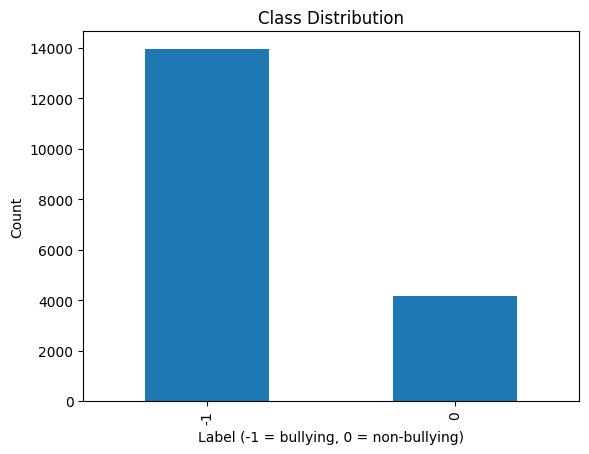

In [15]:
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Label (-1 = bullying, 0 = non-bullying)")
plt.ylabel("Count")
plt.show()

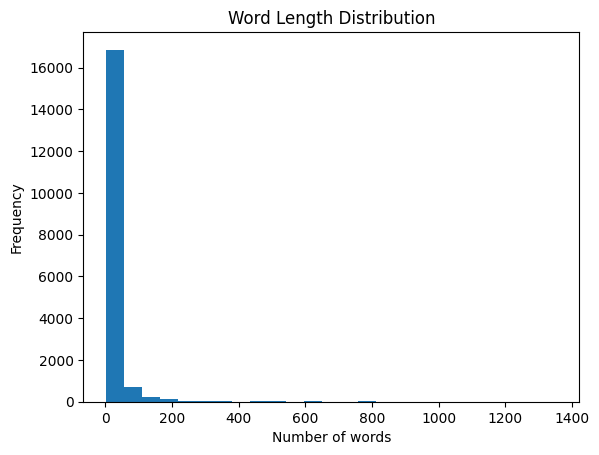

In [16]:
plt.hist(df["word_len"], bins=25)
plt.title("Word Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

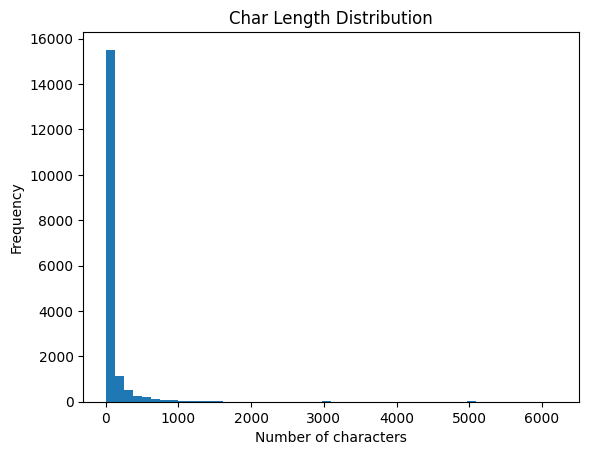

In [17]:
plt.hist(df["char_len"], bins=50)
plt.title("Char Length Distribution")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

In [18]:
def get_top_words(texts, n=20):
    all_words = " ".join(texts).split()
    return Counter(all_words).most_common(n)

print("Top words in label -1 (bullying):")
print(get_top_words(df[df["label"] == -1]["text"]))

print("\nTop words in label 0 (non-bullying):")
print(get_top_words(df[df["label"] == 0]["text"]))

Top words in label -1 (bullying):
[('you', 9048), ('fuck', 8330), ('dunga', 6040), ('kar', 5266), ('the', 4667), ('nahi', 4069), ('a', 3679), ('i', 3619), ('to', 3230), ('and', 2994), ('suck', 2614), ('is', 2207), ('shit', 2109), ('toh', 2014), ('me', 1999), ('ass', 1898), ('tujhe', 1887), ('tak', 1781), ('pe', 1780), ('mat', 1743)]

Top words in label 0 (non-bullying):
[('the', 7626), ('to', 3829), ('of', 3108), ('i', 2883), ('a', 2808), ('and', 2796), ('you', 2479), ('is', 2404), ('that', 2182), ('in', 1990), ('it', 1874), ('for', 1325), ('this', 1232), ('not', 1209), ('on', 1202), ('be', 1129), ('as', 977), ('s', 925), ('are', 912), ('have', 850)]


## 3. Hinglish vs. English Analysis

This section analyzes the merged corpus to ensure the intended behavior for both Hinglish and English language groups, fulfilling the requirement for a 75% Hinglish majority.

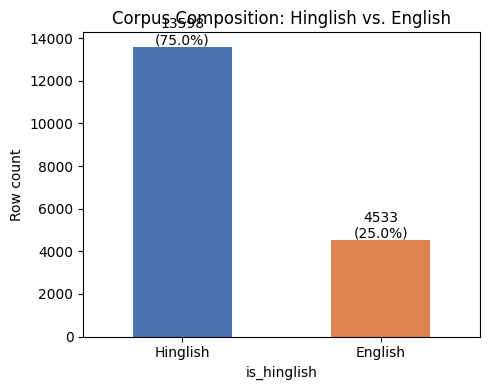

In [19]:
lang_counts = df["is_hinglish"].value_counts().rename({True: "Hinglish", False: "English"})
plt.figure(figsize=(5, 4))
lang_counts.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Corpus Composition: Hinglish vs. English")
plt.ylabel("Row count")
plt.xticks(rotation=0)
for i, v in enumerate(lang_counts.values):
    plt.text(i, v + 100, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
plt.tight_layout()
plt.show()

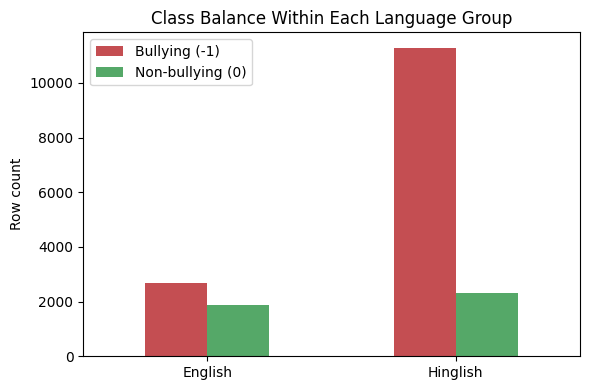

          Bullying (-1)  Non-bullying (0)
English            2675              1858
Hinglish          11284              2314

Hinglish text is proportionally *more* skewed toward bullying (~84%) than English text (~59%)
-- consistent with the source Hinglish data leaning heavily on extortion/threat-style content.


In [20]:
lang_label = df.groupby(["is_hinglish", "label"]).size().unstack()
lang_label.index = ["English", "Hinglish"]
lang_label.columns = ["Bullying (-1)", "Non-bullying (0)"]
ax = lang_label.plot(kind="bar", stacked=False, figsize=(6, 4), color=["#C44E52", "#55A868"])
plt.title("Class Balance Within Each Language Group")
plt.ylabel("Row count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(lang_label)
print("\nHinglish text is proportionally *more* skewed toward bullying (~84%) than English text (~59%)")
print("-- consistent with the source Hinglish data leaning heavily on extortion/threat-style content.")

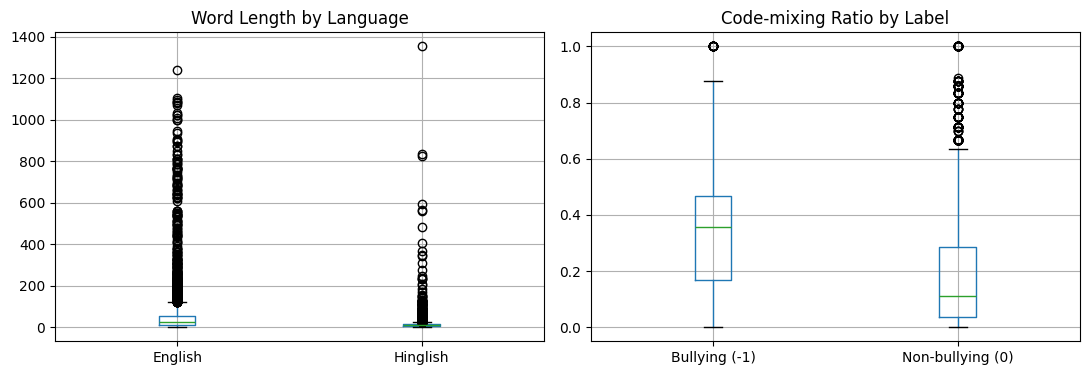

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.boxplot(column="word_len", by="is_hinglish", ax=axes[0])
axes[0].set_xticklabels(["English", "Hinglish"])
axes[0].set_title("Word Length by Language")
axes[0].set_xlabel("")

df.boxplot(column="hinglish_ratio", by="label", ax=axes[1])
axes[1].set_xticklabels(["Bullying (-1)", "Non-bullying (0)"])
axes[1].set_title("Code-mixing Ratio by Label")
axes[1].set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [22]:
def top_words_for(mask_lang, mask_label, n=15):
    subset = df[(df["is_hinglish"] == mask_lang) & (df["label"] == mask_label)]["text"]
    return get_top_words(subset, n)

print("Top words -- Hinglish, bullying:")
print(top_words_for(True, -1))
print("\nTop words -- Hinglish, non-bullying:")
print(top_words_for(True, 0))
print("\nTop words -- English, bullying:")
print(top_words_for(False, -1))
print("\nTop words -- English, non-bullying:")
print(top_words_for(False, 0))

Top words -- Hinglish, bullying:
[('dunga', 6033), ('kar', 5265), ('nahi', 4069), ('the', 2016), ('toh', 2014), ('tujhe', 1880), ('tak', 1780), ('pe', 1775), ('mat', 1741), ('warna', 1573), ('hai', 1564), ('teri', 1519), ('ko', 1493), ('dekh', 1468), ('raha', 1389)]

Top words -- Hinglish, non-bullying:
[('the', 2223), ('hai', 668), ('of', 591), ('to', 410), ('is', 352), ('ke', 348), ('ko', 306), ('and', 303), ('in', 301), ('a', 267), ('i', 259), ('that', 245), ('le', 241), ('me', 237), ('baad', 229)]

Top words -- English, bullying:
[('you', 8804), ('fuck', 7702), ('i', 3512), ('a', 3493), ('and', 2854), ('the', 2651), ('suck', 2516), ('to', 2216), ('shit', 2047), ('is', 1982), ('are', 1618), ('s', 1569), ('of', 1543), ('ass', 1390), ('your', 1374)]

Top words -- English, non-bullying:
[('the', 5403), ('to', 3419), ('i', 2624), ('a', 2541), ('of', 2517), ('and', 2493), ('you', 2287), ('is', 2052), ('that', 1937), ('in', 1689), ('it', 1657), ('for', 1167), ('this', 1115), ('not', 1083)

### 3.1 Word Clouds by Language and Class

Visualizing word clouds to assess the distinctiveness of bullying/non-bullying vocabularies across language groups.

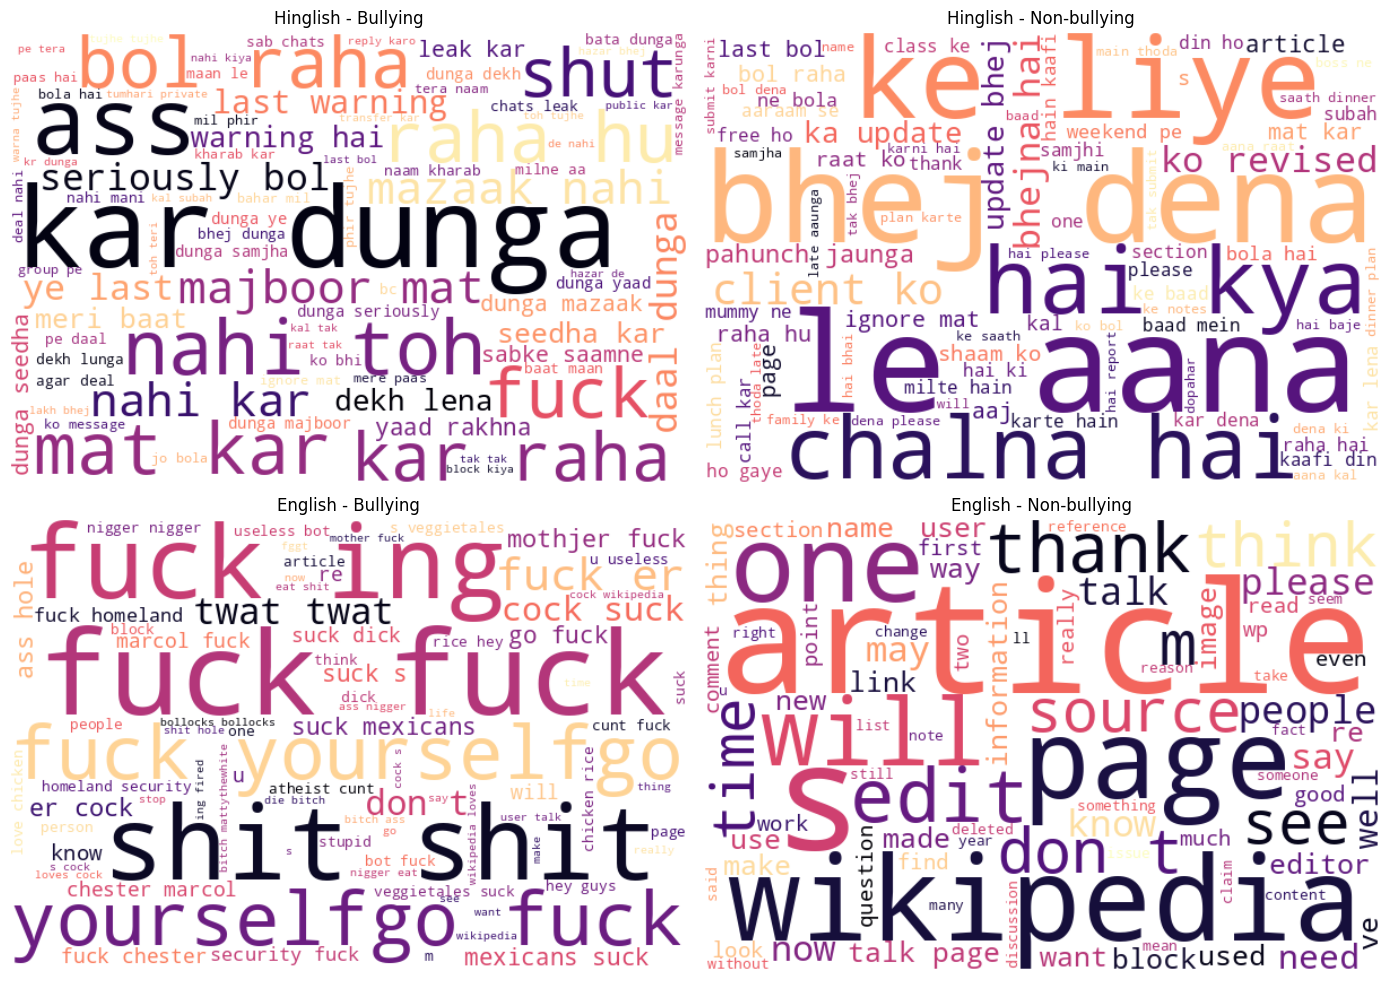

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
configs = [
    (True, -1, "Hinglish - Bullying"),
    (True, 0, "Hinglish - Non-bullying"),
    (False, -1, "English - Bullying"),
    (False, 0, "English - Non-bullying"),
]
for ax, (is_h, lbl, title) in zip(axes.flat, configs):
    subset = df[(df["is_hinglish"] == is_h) & (df["label"] == lbl)]["text"]
    text_blob = " ".join(subset.sample(min(2000, len(subset)), random_state=RANDOM_STATE))
    wc = WordCloud(width=600, height=400, background_color="white", colormap="magma", max_words=80).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

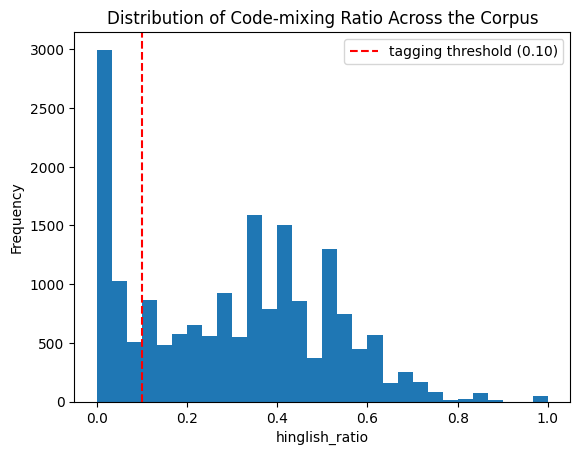

In [24]:
plt.hist(df["hinglish_ratio"], bins=30)
plt.title("Distribution of Code-mixing Ratio Across the Corpus")
plt.xlabel("hinglish_ratio")
plt.ylabel("Frequency")
plt.axvline(0.10, color="red", linestyle="--", label="tagging threshold (0.10)")
plt.legend()
plt.show()

## 4. Text Preprocessing Pipeline

The preprocessing pipeline includes chat-word expansion, punctuation stripping, tokenization, and optional stopword removal/stemming/lemmatization. Lexicons for chat words and stopwords have been widened to account for the 75% Hinglish corpus.

In [25]:
chat_words = {
    "u": "you", "ur": "your", "r": "are", "n": "and",
    "bcz": "because", "bcuz": "because", "coz": "because",
    "idk": "i do not know", "imo": "in my opinion", "imho": "in my humble opinion",
    "btw": "by the way", "lol": "laughing", "omg": "oh my god", "wtf": "what the fuck",
    "pls": "please", "plz": "please", "thx": "thanks", "fr": "for real",
    "bro": "brother", "msg": "message", "dm": "direct message",
    "cant": "can not", "dont": "do not", "wont": "will not", "aint": "is not",
    "ya": "you", "k": "okay", "ok": "okay",
    # Hinglish-chat additions
    "kyu": "kyun", "kyun": "kyun", "tmhe": "tumhe", "tme": "tumhe", "mje": "mujhe",
    "kaha": "kahan", "krna": "karna", "krlo": "kar lo", "krdiya": "kar diya",
    "acha": "accha", "thik": "theek", "nhi": "nahi", "nai": "nahi",
    "hme": "humein", "apko": "aapko", "aapko": "aapko", "rha": "raha", "rhi": "rahi",
}

In [26]:
eng_stopwords = set(stopwords.words("english"))

# keep some pronouns because they may matter in abuse detection
keep_words = {"you", "your", "yours", "he", "she", "they", "them", "their"}
custom_stopwords = eng_stopwords - keep_words

In [27]:
hinglish_stopwords = {
    "hai", "tha", "thi", "the", "ho", "hoga", "hogi", "kar", "karo",
    "raha", "rahi", "rahe", "mein", "main", "par", "aur", "toh",
    # widened for a 75%-Hinglish corpus
    "hain", "karna", "karta", "karti", "karte", "hua", "hue", "hui",
    "koi", "kuch", "bhi", "hi", "ye", "yeh", "wo", "woh", "se", "ka", "ki", "ke",
}

all_stopwords = custom_stopwords.union(hinglish_stopwords)

In [28]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
spell = SpellChecker()

In [29]:
def clean_basic(text):
    text = str(text)

    # remove emojis
    text = re.sub(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FA6F"
        "\U0001FA70-\U0001FAFF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        "",
        text
    )

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # remove html tags
    text = re.sub(r'<.*?>', ' ', text)

    # remove usernames / mentions
    text = re.sub(r'@\w+', ' ', text)

    # remove numbers (optional)
    text = re.sub(r'\d+', ' ', text)

    # normalize repeated letters: coooool -> cool
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [30]:
def expand_chat_words(text):
    words = text.split()
    expanded = [chat_words.get(word, word) for word in words]
    return " ".join(expanded)

In [31]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [32]:
def tokenize_text(text):
    return word_tokenize(text)

In [33]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in all_stopwords]

In [34]:
def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

In [35]:
def lemmatize_text_spacy(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if not token.is_space])

In [36]:
def pos_tags_spacy(text):
    doc = nlp(text)
    return [(token.text, token.pos_) for token in doc]

In [37]:
def light_spelling_correction(tokens):
    corrected = []
    for word in tokens:
        # do not correct short words or abusive slang-like tokens too aggressively
        if len(word) <= 3:
            corrected.append(word)
            continue

        corrected_word = spell.correction(word)
        if corrected_word is None:
            corrected.append(word)
        else:
            corrected.append(corrected_word)
    return corrected

In [38]:
def preprocess_text(
    text,
    use_chat_words=True,
    use_punctuation_removal=True,
    use_stopwords=False,
    use_stemming=False,
    use_lemmatization=True,
    use_spelling=False
):
    text = clean_basic(text)

    if use_chat_words:
        text = expand_chat_words(text)

    if use_punctuation_removal:
        text = remove_punctuation(text)

    tokens = tokenize_text(text)

    if use_spelling:
        tokens = light_spelling_correction(tokens)

    if use_stopwords:
        tokens = remove_stopwords(tokens)

    if use_stemming:
        tokens = stem_tokens(tokens)

    text = " ".join(tokens)

    if use_lemmatization:
        text = lemmatize_text_spacy(text)

    return text

In [39]:
df["clean_text"] = df["text"].apply(
    lambda x: preprocess_text(
        x,
        use_chat_words=True,
        use_punctuation_removal=True,
        use_stopwords=False,
        use_stemming=False,
        use_lemmatization=False,
        use_spelling=False
    )
)

df["clean_lemma"] = df["text"].apply(
    lambda x: preprocess_text(
        x,
        use_chat_words=True,
        use_punctuation_removal=True,
        use_stopwords=False,
        use_stemming=False,
        use_lemmatization=True,
        use_spelling=False
    )
)

df["clean_stop_lemma"] = df["text"].apply(
    lambda x: preprocess_text(
        x,
        use_chat_words=True,
        use_punctuation_removal=True,
        use_stopwords=True,
        use_stemming=False,
        use_lemmatization=True,
        use_spelling=False
    )
)

df[["text", "clean_text", "clean_lemma", "clean_stop_lemma"]].head()

,text,clean_text,clean_lemma,clean_stop_lemma
0,paise kal tak de nahi toh teri private nude ph...,paise kal tak de nahi toh teri private nude ph...,paise kal tak de nahi toh teri private nude ph...,paise kal tak de nahi teri private nude photo ...
1,papa ke liye groceries le aana shaam ko.,papa ke liye groceries le aana shaam ko,papa ke liye groceries le aana shaam ko,papa liye groceries le aana shaam ko
2,"50 hazar de, otherwise terey videos viral kar ...",hazar de otherwise terey videos viral kar dung...,hazar de otherwise terey video viral kar dunga...,hazar de otherwise terey video viral dunga see...
3,ghar kab aa raha hai please abhi abhi,ghar kab aa raha hai please abhi abhi,ghar kab aa raha hai please abhi abhi,ghar kab aa please abhi abhi
4,"meri baat maan le, nahi toh tere classmates ko...",meri baat maan le nahi toh tere classmates ko ...,meri baat maan le nahi toh tere classmate ko b...,meri baat maan le nahi tere classmate ko call ...


## 5. Feature Engineering

Feature engineering includes POS counts, simple and advanced structural features, and fuzzy-match abuse scores. The `abuse_words` lexicon has been expanded to include Hinglish terms. `hinglish_ratio` and `is_hinglish` are also incorporated as model features.

In [40]:
def pos_feature_counts(text):
    doc = nlp(text)
    pos_counts = Counter([token.pos_ for token in doc])
    return {
        'noun_count': pos_counts.get('NOUN', 0),
        'verb_count': pos_counts.get('VERB', 0),
        'adj_count': pos_counts.get('ADJ', 0),
        'adv_count': pos_counts.get('ADV', 0),
        'pron_count': pos_counts.get('PRON', 0)
    }

pos_df = df['clean_text'].apply(pos_feature_counts).apply(pd.Series)
df = pd.concat([df, pos_df], axis=1)

In [41]:
abuse_words = {
    # English
    "fuck", "shit", "bitch", "bastard", "idiot", "stupid", "moron",
    "suck", "gay", "filthy", "ass", "fool", "nonsense", "cunt", "whore",
    "slut", "dick", "pussy", "nigger", "retard", "loser",
    # Hindi / Hinglish (Roman script) -- needed because the corpus is 75% Hinglish
    "chutiya", "chutiye", "bhosdi", "bhosdike", "randi", "gaandu", "gandu",
    "bhadva", "bhadve", "harami", "haramzada", "kutta", "kutti", "kamina",
    "kameena", "kameeni", "saala", "saale", "saali", "chodu", "lund",
    "madarchod", "behenchod", "bhenchod", "bkc", "mc", "bc",
}

def count_abuse_words(text):
    words = text.split()
    return sum(1 for w in words if w in abuse_words)

def extract_simple_features(text):
    return {
        "char_len": len(text),
        "word_len": len(text.split()),
        "exclamation_count": text.count("!"),
        "question_count": text.count("?"),
        "capital_ratio": sum(1 for c in text if c.isupper()) / (len(text) + 1),
        "abuse_count": count_abuse_words(text.lower()),
        "unique_word_ratio": len(set(text.split())) / (len(text.split()) + 1)
    }

simple_feat_df = df['text'].apply(extract_simple_features).apply(pd.Series)
df = pd.concat([df, simple_feat_df], axis=1)

In [42]:
def extract_advanced_features(text):
    words = text.split()
    return {
        "avg_word_len": np.mean([len(w) for w in words]) if words else 0,
        "digit_count": sum(c.isdigit() for c in text),
        "punct_count": sum(c in string.punctuation for c in text),
        "repeated_char_patterns": len(re.findall(r'(.)\1{2,}', text.lower())),
        "repeated_punct_patterns": len(re.findall(r'([!?])\1{1,}', text)),
        "contains_url": int(bool(re.search(r'http\S+|www\S+', text))),
        "contains_mention": int(bool(re.search(r'@\w+', text))),
    }

adv_feat_df = df['text'].apply(extract_advanced_features).apply(pd.Series)
df = pd.concat([df, adv_feat_df], axis=1)

In [43]:
abuse_lexicon = list(abuse_words)

def max_fuzzy_abuse_score(text):
    tokens = text.lower().split()
    if not tokens:
        return 0
    max_score = 0
    for token in tokens:
        for abuse in abuse_lexicon:
            score = fuzz.ratio(token, abuse)
            if score > max_score:
                max_score = score
    return max_score

df['fuzzy_abuse_score'] = df['text'].apply(max_fuzzy_abuse_score)

In [44]:
print("Top words in label -1:")
print(get_top_words(df[df['label'] == -1]['text']))

print("\nTop words in label 0:")
print(get_top_words(df[df['label'] == 0]['text']))

Top words in label -1:
[('you', 9048), ('fuck', 8330), ('dunga', 6040), ('kar', 5266), ('the', 4667), ('nahi', 4069), ('a', 3679), ('i', 3619), ('to', 3230), ('and', 2994), ('suck', 2614), ('is', 2207), ('shit', 2109), ('toh', 2014), ('me', 1999), ('ass', 1898), ('tujhe', 1887), ('tak', 1781), ('pe', 1780), ('mat', 1743)]

Top words in label 0:
[('the', 7626), ('to', 3829), ('of', 3108), ('i', 2883), ('a', 2808), ('and', 2796), ('you', 2479), ('is', 2404), ('that', 2182), ('in', 1990), ('it', 1874), ('for', 1325), ('this', 1232), ('not', 1209), ('on', 1202), ('be', 1129), ('as', 977), ('s', 925), ('are', 912), ('have', 850)]


In [45]:
feature_cols = [
    'char_len', 'word_len', 'exclamation_count', 'question_count',
    'capital_ratio', 'abuse_count', 'unique_word_ratio',
    'avg_word_len', 'digit_count', 'punct_count',
    'repeated_char_patterns', 'repeated_punct_patterns',
    'contains_url', 'contains_mention', 'fuzzy_abuse_score',
    'noun_count', 'verb_count', 'adj_count', 'adv_count', 'pron_count',
    'hinglish_ratio', 'is_hinglish',
]

df['is_hinglish'] = df['is_hinglish'].astype(int)  # numeric for modelling

# de-duplicate any accidentally repeated columns from the concat steps above
df = df.loc[:, ~df.columns.duplicated()]

print("Total custom features:", len(feature_cols))
df[feature_cols].describe().T

Total custom features: 22


,count,mean,std,min,25%,50%,75%,max
char_len,18131.0,133.788760,341.829828,3.000000,49.000000,73.000000,90.500000,6203.000000
word_len,18131.0,24.936297,63.154311,1.000000,10.000000,13.000000,17.000000,1354.000000
exclamation_count,18131.0,0.005571,0.117999,0.000000,0.000000,0.000000,0.000000,6.000000
question_count,18131.0,0.131157,0.430633,0.000000,0.000000,0.000000,0.000000,21.000000
capital_ratio,18131.0,0.038458,0.159382,0.000000,0.000000,0.000000,0.000000,0.839080
abuse_count,18131.0,1.164690,18.444954,0.000000,0.000000,0.000000,0.000000,1239.000000
unique_word_ratio,18131.0,0.864749,0.100201,0.000999,0.846154,0.888889,0.928571,0.971429
avg_word_len,18131.0,4.370604,0.646024,1.454545,3.964157,4.367713,4.750000,23.285714
digit_count,18131.0,0.203960,0.871620,0.000000,0.000000,0.000000,0.000000,24.000000
punct_count,18131.0,1.116044,1.396154,0.000000,0.000000,1.000000,2.000000,23.000000


## 6. Train / Test Split

The data is split into training and testing sets, stratified by label and language to preserve the Hinglish/English ratio and class balance.

In [46]:
df['_strata'] = df['label'].astype(str) + "_" + df['is_hinglish'].astype(str)

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['_strata']
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Train language mix:\n", df.loc[X_train.index, 'is_hinglish'].value_counts(normalize=True))
print("Test language mix:\n", df.loc[X_test.index, 'is_hinglish'].value_counts(normalize=True))

Train size: 14504  Test size: 3627
Train language mix:
 is_hinglish
1    0.75
0    0.25
Name: proportion, dtype: float64
Test language mix:
 is_hinglish
1    0.749931
0    0.250069
Name: proportion, dtype: float64


## 7. NLP

This section benchmarks various classical machine learning models including Bag-of-Words, TF-IDF (word, char, and combined), custom features, Word2Vec (CBOW & Skip-gram), and FastText, using Logistic Regression, LinearSVC, and MultinomialNB classifiers.

In [47]:
bow_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=20000, ngram_range=(1,2), min_df=2)),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

bow_pipeline.fit(X_train, y_train)
bow_pred = bow_pipeline.predict(X_test)
print("BOW accuracy:",  accuracy_score(y_test, bow_pred))
print("BoW F1:", f1_score(y_test, bow_pred, average='macro'))
print(classification_report(y_test, bow_pred))

BOW accuracy: 0.9649848359525779
BoW F1: 0.9518948688131594
              precision    recall  f1-score   support

          -1       0.99      0.97      0.98      2792
           0       0.89      0.96      0.93       835

    accuracy                           0.96      3627
   macro avg       0.94      0.96      0.95      3627
weighted avg       0.97      0.96      0.97      3627



In [48]:
tfidf_word_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=30000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))
])

tfidf_word_pipeline.fit(X_train, y_train)
pred_word = tfidf_word_pipeline.predict(X_test)
print("TF-IDF accuracy:",  accuracy_score(y_test, pred_word))
print("TF-IDF Word F1:", f1_score(y_test, pred_word, average='macro'))
print(classification_report(y_test, pred_word))

TF-IDF accuracy: 0.9465122690929143
TF-IDF Word F1: 0.9288527262211472
              precision    recall  f1-score   support

          -1       0.99      0.94      0.96      2792
           0       0.83      0.97      0.89       835

    accuracy                           0.95      3627
   macro avg       0.91      0.96      0.93      3627
weighted avg       0.95      0.95      0.95      3627



In [49]:
tfidf_char_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3,5),
        min_df=2,
        max_features=40000,
        sublinear_tf=True
    )),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))
])

tfidf_char_pipeline.fit(X_train, y_train)
pred_char = tfidf_char_pipeline.predict(X_test)
print("TF-IDF char accuracy:",  accuracy_score(y_test, pred_char))
print("TF-IDF Char F1:", f1_score(y_test, pred_char, average='macro'))
print(classification_report(y_test, pred_char))

TF-IDF char accuracy: 0.9495450785773366
TF-IDF Char F1: 0.9326648455409523
              precision    recall  f1-score   support

          -1       0.99      0.94      0.97      2792
           0       0.83      0.97      0.90       835

    accuracy                           0.95      3627
   macro avg       0.91      0.96      0.93      3627
weighted avg       0.96      0.95      0.95      3627



In [50]:
word_vectorizer = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,5),
    min_df=2,
    max_features=30000,
    sublinear_tf=True
)

X_train_word = word_vectorizer.fit_transform(X_train)
X_test_word = word_vectorizer.transform(X_test)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

X_train_tfidf_combined = hstack([X_train_word, X_train_char])
X_test_tfidf_combined = hstack([X_test_word, X_test_char])

clf = LogisticRegression(max_iter=3000, class_weight='balanced')
clf.fit(X_train_tfidf_combined, y_train)
pred_combined = clf.predict(X_test_tfidf_combined)
print("TF-IDF Word+Char accuracy:",  accuracy_score(y_test, pred_combined))
print("TF-IDF Word+Char F1:", f1_score(y_test, pred_combined, average='macro'))
print(classification_report(y_test, pred_combined))

TF-IDF Word+Char accuracy: 0.9556106975461814
TF-IDF Word+Char F1: 0.9400466631245813
              precision    recall  f1-score   support

          -1       0.99      0.95      0.97      2792
           0       0.86      0.97      0.91       835

    accuracy                           0.96      3627
   macro avg       0.92      0.96      0.94      3627
weighted avg       0.96      0.96      0.96      3627



In [51]:
X_train_num = df.loc[X_train.index, feature_cols].values
X_test_num  = df.loc[X_test.index, feature_cols].values

scaler = StandardScaler(with_mean=False)
X_train_num = scaler.fit_transform(X_train_num)
X_test_num  = scaler.transform(X_test_num)

X_train_final = hstack([X_train_tfidf_combined, csr_matrix(X_train_num)])
X_test_final  = hstack([X_test_tfidf_combined, csr_matrix(X_test_num)])

final_lr = LogisticRegression(max_iter=4000, class_weight='balanced')
final_lr.fit(X_train_final, y_train)
pred_final_lr = final_lr.predict(X_test_final)
print("TF-IDF + Custom Features accuracy:",  accuracy_score(y_test, pred_final_lr))
print("TF-IDF + Custom Features F1:", f1_score(y_test, pred_final_lr, average='macro'))
print(classification_report(y_test, pred_final_lr))

TF-IDF + Custom Features accuracy: 0.967741935483871
TF-IDF + Custom Features F1: 0.9558566575871419
              precision    recall  f1-score   support

          -1       0.99      0.97      0.98      2792
           0       0.89      0.97      0.93       835

    accuracy                           0.97      3627
   macro avg       0.94      0.97      0.96      3627
weighted avg       0.97      0.97      0.97      3627



In [52]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=4000, class_weight='balanced'),
    "LinearSVC": LinearSVC(class_weight='balanced'),
    "MultinomialNB": MultinomialNB()
}

model_preds = {}
for name, model in models.items():
    if name == "MultinomialNB":
        model.fit(X_train_word, y_train)
        pred = model.predict(X_test_word)
    else:
        model.fit(X_train_final, y_train)
        pred = model.predict(X_test_final)
    model_preds[name] = pred

    print("="*60)
    print(name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Macro F1:", f1_score(y_test, pred, average='macro'))
    print(classification_report(y_test, pred))

LogisticRegression
Accuracy: 0.967741935483871
Macro F1: 0.9558566575871419
              precision    recall  f1-score   support

          -1       0.99      0.97      0.98      2792
           0       0.89      0.97      0.93       835

    accuracy                           0.97      3627
   macro avg       0.94      0.97      0.96      3627
weighted avg       0.97      0.97      0.97      3627

LinearSVC
Accuracy: 0.9735318444995864
Macro F1: 0.9633605830788929
              precision    recall  f1-score   support

          -1       0.99      0.97      0.98      2792
           0       0.92      0.97      0.94       835

    accuracy                           0.97      3627
   macro avg       0.96      0.97      0.96      3627
weighted avg       0.97      0.97      0.97      3627

MultinomialNB
Accuracy: 0.9338296112489661
Macro F1: 0.9116590417348309
              precision    recall  f1-score   support

          -1       0.98      0.93      0.96      2792
           0       0.

In [53]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

X_train_tokens = df.loc[X_train.index, 'tokens']
X_test_tokens = df.loc[X_test.index, 'tokens']

In [54]:
w2v_cbow = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=0   # CBOW
)

w2v_skipgram = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1   # Skip-gram
)

In [55]:
def avg_word_vectors(tokens, model, size):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(size)
    return np.mean(valid_vectors, axis=0)

X_train_cbow = np.array([avg_word_vectors(tokens, w2v_cbow, 100) for tokens in X_train_tokens])
X_test_cbow = np.array([avg_word_vectors(tokens, w2v_cbow, 100) for tokens in X_test_tokens])

X_train_skip = np.array([avg_word_vectors(tokens, w2v_skipgram, 100) for tokens in X_train_tokens])
X_test_skip = np.array([avg_word_vectors(tokens, w2v_skipgram, 100) for tokens in X_test_tokens])

In [56]:
lr_cbow = LogisticRegression(max_iter=3000, class_weight='balanced')
lr_cbow.fit(X_train_cbow, y_train)
pred_cbow = lr_cbow.predict(X_test_cbow)
print("Word2Vec CBOW accuracy:",  accuracy_score(y_test, pred_cbow))
print("Word2Vec CBOW F1:", f1_score(y_test, pred_cbow, average='macro'))
print(classification_report(y_test, pred_cbow))

Word2Vec CBOW accuracy: 0.9241797628894403
Word2Vec CBOW F1: 0.9008973562195683
              precision    recall  f1-score   support

          -1       0.99      0.92      0.95      2792
           0       0.77      0.95      0.85       835

    accuracy                           0.92      3627
   macro avg       0.88      0.93      0.90      3627
weighted avg       0.94      0.92      0.93      3627



In [57]:
lr_skip = LogisticRegression(max_iter=3000, class_weight='balanced')
lr_skip.fit(X_train_skip, y_train)
pred_skip = lr_skip.predict(X_test_skip)
print("Word2Vec Skip-gram accuracy:",  accuracy_score(y_test, pred_skip))
print("Word2Vec Skip-gram F1:", f1_score(y_test, pred_skip, average='macro'))
print(classification_report(y_test, pred_skip))

Word2Vec Skip-gram accuracy: 0.9332781913427075
Word2Vec Skip-gram F1: 0.9121412716029809
              precision    recall  f1-score   support

          -1       0.99      0.92      0.96      2792
           0       0.79      0.96      0.87       835

    accuracy                           0.93      3627
   macro avg       0.89      0.94      0.91      3627
weighted avg       0.94      0.93      0.94      3627



In [58]:
ft_model = FastText(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

X_train_ft = np.array([avg_word_vectors(tokens, ft_model, 100) for tokens in X_train_tokens])
X_test_ft = np.array([avg_word_vectors(tokens, ft_model, 100) for tokens in X_test_tokens])

In [59]:
lr_ft = LogisticRegression(max_iter=3000, class_weight='balanced')
lr_ft.fit(X_train_ft, y_train)
pred_ft = lr_ft.predict(X_test_ft)
print("FastText accuracy:",  accuracy_score(y_test, pred_ft))
print("FastText F1:", f1_score(y_test, pred_ft, average='macro'))
print(classification_report(y_test, pred_ft))

FastText accuracy: 0.931899641577061
FastText F1: 0.9102300141137851
              precision    recall  f1-score   support

          -1       0.99      0.92      0.95      2792
           0       0.79      0.96      0.87       835

    accuracy                           0.93      3627
   macro avg       0.89      0.94      0.91      3627
weighted avg       0.94      0.93      0.93      3627



In [60]:
results = []

def add_result(name, y_true, pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision_macro": precision_score(y_true, pred, average='macro'),
        "Recall_macro": recall_score(y_true, pred, average='macro'),
        "F1_macro": f1_score(y_true, pred, average='macro')
    })

add_result("BoW + LR", y_test, bow_pred)
add_result("TF-IDF Word + LR", y_test, pred_word)
add_result("TF-IDF Char + LR", y_test, pred_char)
add_result("TF-IDF Word+Char + LR", y_test, pred_combined)
add_result("TF-IDF Word+Char+Custom + LR", y_test, pred_final_lr)
add_result("TF-IDF Word+Char+Custom + LinearSVC", y_test, model_preds["LinearSVC"])
add_result("TF-IDF Word+Char+Custom + MultinomialNB (word only)", y_test, model_preds["MultinomialNB"])
add_result("Word2Vec CBOW + LR", y_test, pred_cbow)
add_result("Word2Vec Skipgram + LR", y_test, pred_skip)
add_result("FastText + LR", y_test, pred_ft)

results_df = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False)
results_df

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
5,TF-IDF Word+Char+Custom + LinearSVC,0.973532,0.955153,0.972315,0.963361
4,TF-IDF Word+Char+Custom + LR,0.967742,0.943388,0.970233,0.955857
0,BoW + LR,0.964985,0.940983,0.964245,0.951895
3,TF-IDF Word+Char + LR,0.955611,0.923650,0.960255,0.940047
2,TF-IDF Char + LR,0.949545,0.913047,0.958414,0.932665
1,TF-IDF Word + LR,0.946512,0.908527,0.956024,0.928853
8,Word2Vec Skipgram + LR,0.933278,0.890227,0.943231,0.912141
6,TF-IDF Word+Char+Custom + MultinomialNB (word ...,0.933830,0.893137,0.936034,0.911659
9,FastText + LR,0.931900,0.888666,0.940657,0.910230
7,Word2Vec CBOW + LR,0.924180,0.878069,0.934803,0.900897


## 8. Hyperparameter Tuning & Final Classical Model (LinearSVC)

Grid-search `LinearSVC` over the TF-IDF(word+char) + custom-features representation, optimising for macro-F1 — the same approach validated in the previous version of this notebook (which found LinearSVC + TF-IDF word+char + custom features to be the strongest classical configuration).


In [61]:
param_grid = {
    "C": [0.1, 0.5, 1, 2, 5],
    "tol": [1e-3, 1e-4],
    "loss": ["hinge", "squared_hinge"]
}

grid = GridSearchCV(
    estimator=LinearSVC(class_weight="balanced", max_iter=5000),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_final, y_train)

print("Best Params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

final_model = grid.best_estimator_
final_pred = final_model.predict(X_test_final)

print("Final Accuracy:", accuracy_score(y_test, final_pred))
print("Final Macro F1:", f1_score(y_test, final_pred, average="macro"))
print(classification_report(y_test, final_pred))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'C': 1, 'loss': 'hinge', 'tol': 0.001}
Best CV F1: 0.9650003709741979
Final Accuracy: 0.9716018748276812
Final Macro F1: 0.9606096452441899
              precision    recall  f1-score   support

          -1       0.99      0.97      0.98      2792
           0       0.92      0.96      0.94       835

    accuracy                           0.97      3627
   macro avg       0.95      0.97      0.96      3627
weighted avg       0.97      0.97      0.97      3627



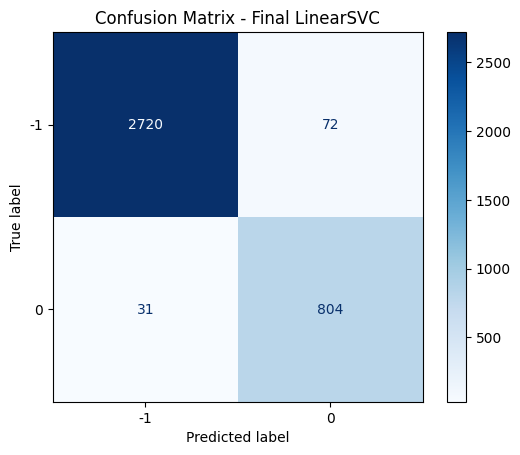

In [62]:
ConfusionMatrixDisplay.from_predictions(y_test, final_pred, cmap="Blues")
plt.title("Confusion Matrix - Final LinearSVC")
plt.show()

## 9. Error Analysis

Error analysis is performed, broken down by language to identify error clusters.

In [63]:
error_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "actual": y_test.reset_index(drop=True),
    "predicted": final_pred,
    "is_hinglish": df.loc[X_test.index, "is_hinglish"].reset_index(drop=True)
})

wrong_preds = error_df[error_df["actual"] != error_df["predicted"]]
print(f"Total errors: {len(wrong_preds)} / {len(error_df)} ({len(wrong_preds)/len(error_df)*100:.2f}%)")
print("\nError rate by language:")
print(error_df.assign(is_wrong=error_df['actual'] != error_df['predicted']).groupby('is_hinglish')['is_wrong'].mean())
wrong_preds.head(20)

Total errors: 103 / 3627 (2.84%)

Error rate by language:
is_hinglish
0    0.084895
1    0.009559
Name: is_wrong, dtype: float64


,text,actual,predicted,is_hinglish
10,god god god i would to mention one big thing t...,-1,0,0
15,way out of line out of line am i your subordin...,-1,0,0
124,pan aah lodo pujara india ne harave che,-1,0,0
222,looking for a conversation we had wanting to r...,0,-1,0
261,a nazi troll is outed by the extreme right as ...,-1,0,0
301,i can only assume its the worlds biggest jerk,-1,0,1
321,kys its the only option,-1,0,1
327,i tried so much aur kitna try karu mein bhi th...,0,-1,1
341,lookin real fugly,-1,0,0
370,ptptpthtphthpth fart fart fart fart fart fart ...,-1,0,0


In [64]:
false_positive = wrong_preds[(wrong_preds["actual"] == 0) & (wrong_preds["predicted"] == -1)]
false_negative = wrong_preds[(wrong_preds["actual"] == -1) & (wrong_preds["predicted"] == 0)]

print("False Positives (flagged clean text as bullying):")
display(false_positive.head(10))

print("False Negatives (missed actual bullying):")
display(false_negative.head(10))

False Positives (flagged clean text as bullying):


,text,actual,predicted,is_hinglish
222,looking for a conversation we had wanting to r...,0,-1,0
327,i tried so much aur kitna try karu mein bhi th...,0,-1,1
919,just the shut the hell up man,0,-1,1
1089,well thank you for spouting your ignorant mout...,0,-1,0
1154,revelvant is this page on ct s really relevant...,0,-1,1
1527,dude are you stupid yankees said hes a hero to...,0,-1,0
1571,nobody cares seriously it s just self referent...,0,-1,1
1685,the biggest dick licker on the planet earth,0,-1,1
1737,why is everyone being such a pussy about this ...,0,-1,0
1747,mereko laga st session mei chase kar lenge abh...,0,-1,1


False Negatives (missed actual bullying):


,text,actual,predicted,is_hinglish
10,god god god i would to mention one big thing t...,-1,0,0
15,way out of line out of line am i your subordin...,-1,0,0
124,pan aah lodo pujara india ne harave che,-1,0,0
261,a nazi troll is outed by the extreme right as ...,-1,0,0
301,i can only assume its the worlds biggest jerk,-1,0,1
321,kys its the only option,-1,0,1
341,lookin real fugly,-1,0,0
370,ptptpthtphthpth fart fart fart fart fart fart ...,-1,0,0
466,a message from shadow i am a wicked homo sex w...,-1,0,0
482,who cares they are worthless scum,-1,0,0


In [65]:
results.append({
    "Model": "TF-IDF Word+Char+Custom + LinearSVC (tuned)",
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision_macro": precision_score(y_test, final_pred, average="macro"),
    "Recall_macro": recall_score(y_test, final_pred, average="macro"),
    "F1_macro": f1_score(y_test, final_pred, average="macro")
})

results_df = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,TF-IDF Word+Char+Custom + LinearSVC,0.973532,0.955153,0.972315,0.963361
1,TF-IDF Word+Char+Custom + LinearSVC (tuned),0.971602,0.953270,0.968543,0.960610
2,TF-IDF Word+Char+Custom + LR,0.967742,0.943388,0.970233,0.955857
3,BoW + LR,0.964985,0.940983,0.964245,0.951895
4,TF-IDF Word+Char + LR,0.955611,0.923650,0.960255,0.940047
5,TF-IDF Char + LR,0.949545,0.913047,0.958414,0.932665
6,TF-IDF Word + LR,0.946512,0.908527,0.956024,0.928853
7,Word2Vec Skipgram + LR,0.933278,0.890227,0.943231,0.912141
8,TF-IDF Word+Char+Custom + MultinomialNB (word ...,0.933830,0.893137,0.936034,0.911659
9,FastText + LR,0.931900,0.888666,0.940657,0.910230


**Classical ML conclusion:** TF-IDF (word + char n-grams) with custom features and a tuned `LinearSVC` remains the strongest classical configuration, outperforming dense embeddings on this dataset.

## 10. Deep Learning — RNN / LSTM / Bi-LSTM

This section benchmarks RNN, LSTM, and Bi-LSTM models against the classical pipeline on the same Hinglish dataset, using tokenized integer sequences padded to a fixed length as input.

In [66]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Embedding, SimpleRNN, LSTM, Bidirectional, Dense, Dropout,
    SpatialDropout1D, Conv1D, MaxPooling1D, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(RANDOM_STATE)

# --- Sequence preparation (shared by every deep model in this section) ---
VOCAB_SIZE = 30000
MAXLEN = int(np.clip(np.percentile(df['word_len'], 95), 20, 60))
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAXLEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAXLEN, padding='post', truncating='post')

# labels: -1 (bullying) -> 1, 0 (non-bullying) -> 0, for binary sigmoid output
y_train_bin = (y_train == -1).astype(int).values
y_test_bin  = (y_test == -1).astype(int).values

class_weight_vals = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train_bin)
class_weight_dict = {0: class_weight_vals[0], 1: class_weight_vals[1]}

actual_vocab = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print("Sequence length (MAXLEN):", MAXLEN)
print("Vocab size in use       :", actual_vocab)
print("Class weights            :", class_weight_dict)

Sequence length (MAXLEN): 60
Vocab size in use       : 18983
Class weights            : {0: np.float64(2.1732094695834583), 1: np.float64(0.6494134503447658)}


In [67]:
from tensorflow.keras.models import Model

def build_sequence_model(kind, vocab_size=actual_vocab, maxlen=MAXLEN, embed_dim=EMBED_DIM, units=64):
    """kind in {'rnn', 'lstm', 'bilstm', 'cnn_bilstm'}"""
    inputs = Input(shape=(maxlen,))
    x = Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)
    x = SpatialDropout1D(0.3)(x)

    if kind == 'rnn':
        x = SimpleRNN(units, dropout=0.2, recurrent_dropout=0.2)(x)
    elif kind == 'lstm':
        x = LSTM(units, dropout=0.2, recurrent_dropout=0.2)(x)
    elif kind == 'bilstm':
        x = Bidirectional(LSTM(units, dropout=0.2, recurrent_dropout=0.2))(x)
    elif kind == 'cnn_bilstm':
        x = Conv1D(filters=64, kernel_size=5, activation='relu', padding='same')(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Bidirectional(LSTM(units, dropout=0.2, recurrent_dropout=0.2))(x)
    else:
        raise ValueError(kind)

    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name=f"childsafelens_{kind}")
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def train_and_evaluate(kind, epochs=10, batch_size=128, label=None):
    label = label or kind.upper()
    model = build_sequence_model(kind)
    model.summary()

    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    history = model.fit(
        X_train_seq, y_train_bin,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=[es],
        verbose=1
    )

    probs = model.predict(X_test_seq, verbose=0).ravel()
    pred_bin = (probs >= 0.5).astype(int)
    pred_labels = np.where(pred_bin == 1, -1, 0)   # map back to the -1/0 scheme used everywhere else

    acc = accuracy_score(y_test_bin, pred_bin)
    f1m = f1_score(y_test_bin, pred_bin, average='macro')
    print(f"\n{label} -> Accuracy: {acc:.4f} | Macro F1: {f1m:.4f}")
    print(classification_report(y_test_bin, pred_bin, target_names=['non-bullying', 'bullying']))

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='val')
    axes[0].set_title(f'{label} - Loss'); axes[0].legend()
    axes[1].plot(history.history['accuracy'], label='train')
    axes[1].plot(history.history['val_accuracy'], label='val')
    axes[1].set_title(f'{label} - Accuracy'); axes[1].legend()
    plt.tight_layout(); plt.show()

    ConfusionMatrixDisplay.from_predictions(y_test_bin, pred_bin, cmap="Purples",
                                             display_labels=['non-bullying', 'bullying'])
    plt.title(f"Confusion Matrix - {label}")
    plt.show()

    add_result(f"{label} (sequence, on-device-infeasible*)", y_test, pred_labels)
    return model, history

### 10.1 Simple RNN


Model: "childsafelens_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 60, 100)        │     1,898,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,910,973 (7.29 MB)

 Trainable params: 1,910,973 (7.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.4951 - loss: 0.7116 - val_accuracy: 0.2150 - val_loss: 0.7140
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5062 - loss: 0.7003 - val_accuracy: 0.7857 - val_loss: 0.6911
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5947 - loss: 0.6922 - val_accuracy: 0.7864 - val_loss: 0.6802
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6947 - loss: 0.6780 - val_accuracy: 0.7877 - val_loss: 0.6675
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6454 - loss: 0.6502 - val_accuracy: 0.5727 - val_loss: 0.5506
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5670 - loss: 0.6268 - val_accuracy: 0.5961 - val_loss: 0.5529
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5379 - loss: 0.6041 - val_accuracy: 0.5252 - val_loss: 0.5608

SimpleRNN -> Accuracy: 0.5840 | Macro F1: 0.5722
              precision    recall  f1-score   supp

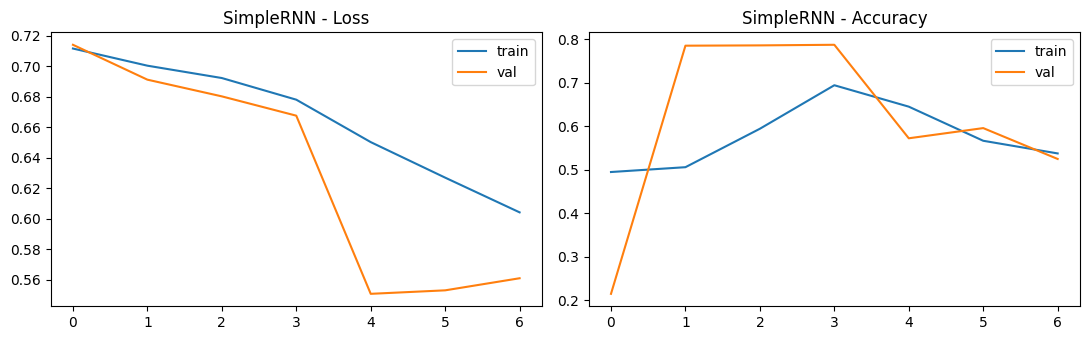

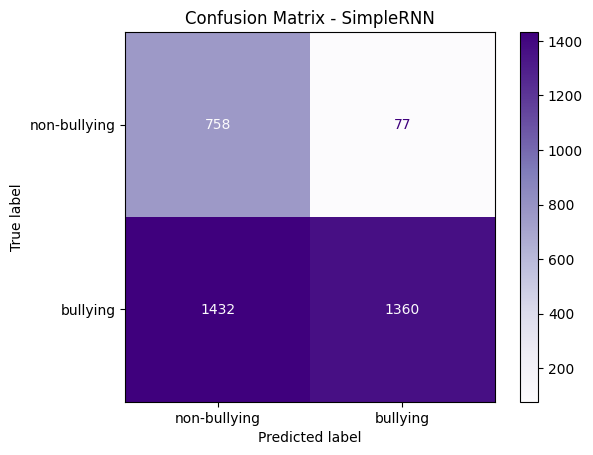

Model: "childsafelens_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 60, 100)        │     1,898,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,732,921 (21.87 MB)

 Trainable params: 1,910,973 (7.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,821,948 (14.58 MB)

In [68]:
rnn_model, rnn_history = train_and_evaluate('rnn', label="SimpleRNN")
rnn_model.summary()

### 10.2 LSTM


Model: "childsafelens_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 60, 100)        │     1,898,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 60, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,942,653 (7.41 MB)

 Trainable params: 1,942,653 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 28s 238ms/step - accuracy: 0.7710 - loss: 0.5800 - val_accuracy: 0.8567 - val_loss: 0.3206
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 22s 213ms/step - accuracy: 0.8970 - loss: 0.3210 - val_accuracy: 0.8663 - val_loss: 0.3965
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 23s 227ms/step - accuracy: 0.8422 - loss: 0.3423 - val_accuracy: 0.8415 - val_loss: 0.3559

LSTM -> Accuracy: 0.8621 | Macro F1: 0.8339
              precision    recall  f1-score   support

non-bullying       0.63      0.98      0.77       835
    bullying       0.99      0.83      0.90      2792

    accuracy                           0.86      3627
   macro avg       0.81      0.90      0.83      3627
weighted avg       0.91      0.86      0.87      3627



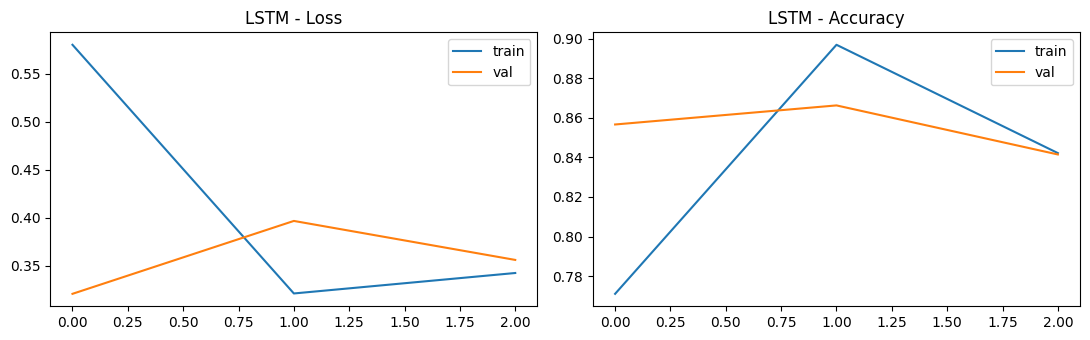

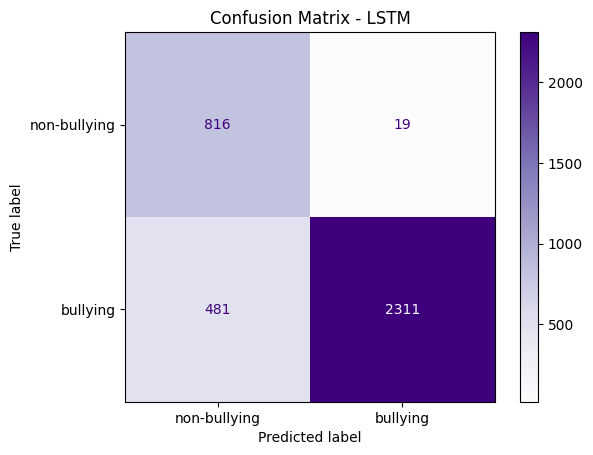

In [70]:
lstm_model, lstm_history = train_and_evaluate('lstm', label="LSTM")

### 10.3 Bidirectional LSTM


Model: "childsafelens_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 60, 100)        │     1,898,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 60, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,986,941 (7.58 MB)

 Trainable params: 1,986,941 (7.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 48s 405ms/step - accuracy: 0.8461 - loss: 0.3294 - val_accuracy: 0.9407 - val_loss: 0.1375
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 401ms/step - accuracy: 0.9615 - loss: 0.0966 - val_accuracy: 0.9559 - val_loss: 0.1179
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 401ms/step - accuracy: 0.9818 - loss: 0.0511 - val_accuracy: 0.9621 - val_loss: 0.1127
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 404ms/step - accuracy: 0.9907 - loss: 0.0322 - val_accuracy: 0.9635 - val_loss: 0.1149
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 82s 412ms/step - accuracy: 0.9950 - loss: 0.0169 - val_accuracy: 0.9635 - val_loss: 0.1512

Bi-LSTM -> Accuracy: 0.9675 | Macro F1: 0.9549
              precision    recall  f1-score   support

non-bullying       0.91      0.95      0.93       835
    bullying       0.99      0.97      0.98      2792

    accuracy                           0.97      3627
   macro avg       0.95      0.96      0.95      3627
weighted avg       0.97  

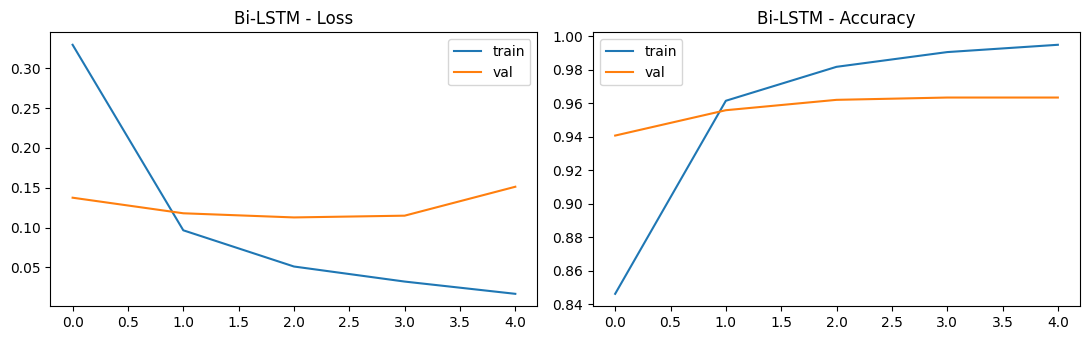

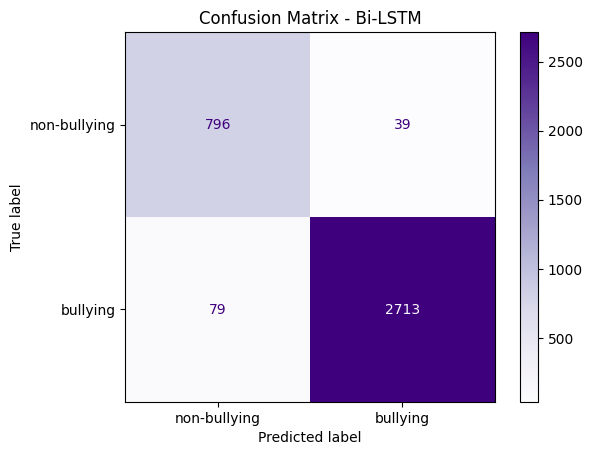

In [72]:
bilstm_model, bilstm_history = train_and_evaluate('bilstm', label="Bi-LSTM")

## 11. Final Model Comparison — Classical vs. Embeddings vs. Deep Learning

This section provides a side-by-side comparison of all trained models (classical, embedding-based, and deep learning models), ranked by macro-F1 score.

In [73]:
results_df = pd.DataFrame(results).drop_duplicates(subset="Model", keep="last").sort_values(by="F1_macro", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,TF-IDF Word+Char+Custom + LinearSVC,0.973532,0.955153,0.972315,0.963361
1,TF-IDF Word+Char+Custom + LinearSVC (tuned),0.971602,0.953270,0.968543,0.960610
2,TF-IDF Word+Char+Custom + LR,0.967742,0.943388,0.970233,0.955857
3,"Bi-LSTM (sequence, on-device-infeasible*)",0.967466,0.947771,0.962499,0.954855
4,BoW + LR,0.964985,0.940983,0.964245,0.951895
5,TF-IDF Word+Char + LR,0.955611,0.923650,0.960255,0.940047
6,TF-IDF Char + LR,0.949545,0.913047,0.958414,0.932665
7,TF-IDF Word + LR,0.946512,0.908527,0.956024,0.928853
8,Word2Vec Skipgram + LR,0.933278,0.890227,0.943231,0.912141
9,TF-IDF Word+Char+Custom + MultinomialNB (word ...,0.933830,0.893137,0.936034,0.911659


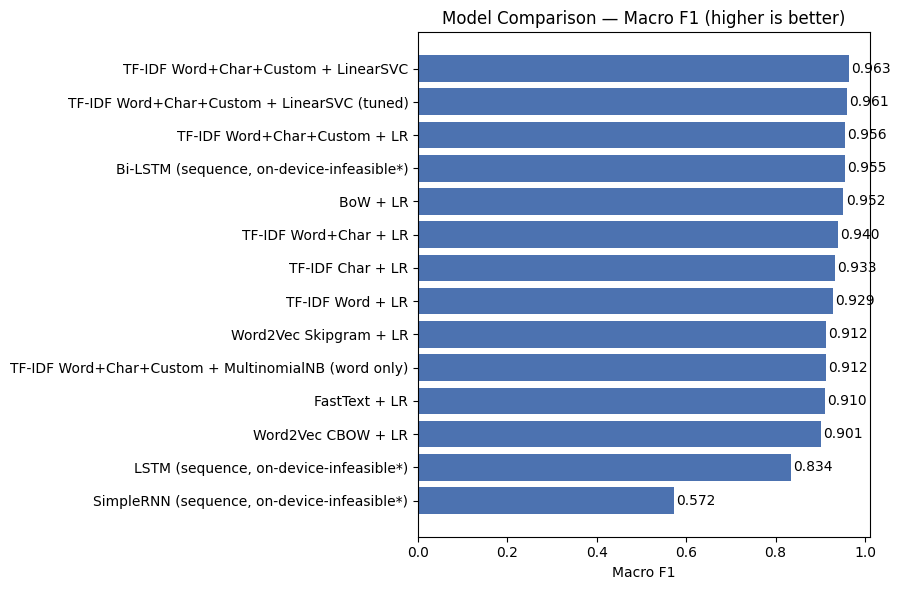

In [74]:
plt.figure(figsize=(9, 6))
plt.barh(results_df["Model"], results_df["F1_macro"], color="#4C72B0")
plt.xlabel("Macro F1")
plt.title("Model Comparison — Macro F1 (higher is better)")
plt.gca().invert_yaxis()
for i, v in enumerate(results_df["F1_macro"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

**Reading the table above:** Compare the performance of the `TF-IDF Word+Char+Custom + LinearSVC (tuned)` model against the deep learning models to determine the best-performing approach.

## 12. Final Production Artifact Export


In [1]:
# joblib.dump(final_model, "final_linearsvc_model.pkl")
# joblib.dump(word_vectorizer, "word_vectorizer.pkl")
# joblib.dump(char_vectorizer, "char_vectorizer.pkl")
# joblib.dump(scaler, "scaler.pkl")
# joblib.dump(feature_cols, "feature_columns.pkl")

# print("Saved classical production pipeline:")
# print(" - final_linearsvc_model.pkl")
# print(" - word_vectorizer.pkl")
# print(" - char_vectorizer.pkl")
# print(" - scaler.pkl")
# print(" - feature_columns.pkl")

In [2]:
# quick round-trip sanity check
# loaded_feature_cols = joblib.load("feature_columns.pkl")
# loaded_scaler = joblib.load("scaler.pkl")

# print("saved feature cols:", len(loaded_feature_cols))
# print("saved scaler expects:", loaded_scaler.n_features_in_)
# assert len(loaded_feature_cols) == loaded_scaler.n_features_in_, "Feature/scaler shape mismatch!"
# print("OK - shapes match")


In [77]:
# Pick the best deep learning model by macro F1 and save it alongside the tokenizer
dl_rows = results_df[results_df["Model"].str.contains("sequence")]

best_dl_row = dl_rows.iloc[0]
best_dl_name = best_dl_row["Model"]
print("Best deep learning model:", best_dl_name, "| Macro F1:", round(best_dl_row["F1_macro"], 4))

dl_models = {
    "SimpleRNN (sequence, on-device-infeasible*)": rnn_model,
    "LSTM (sequence, on-device-infeasible*)": lstm_model,
    "Bi-LSTM (sequence, on-device-infeasible*)": bilstm_model,
}
best_dl_model = dl_models[best_dl_name]
best_dl_model.save("best_deep_learning_model.keras")

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("sequence_config.json", "w") as f:
    json.dump({"maxlen": MAXLEN, "vocab_size": actual_vocab, "embed_dim": EMBED_DIM,
               "label_mapping": {"1": "bullying (-1)", "0": "non-bullying (0)"}}, f, indent=2)

print("Saved best deep learning model -> best_deep_learning_model.keras")
print("Saved tokenizer -> tokenizer.pkl")
print("Saved sequence_config.json")

Best deep learning model: Bi-LSTM (sequence, on-device-infeasible*) | Macro F1: 0.9549
Saved best deep learning model -> best_deep_learning_model.keras
Saved tokenizer -> tokenizer.pkl
Saved sequence_config.json


In [78]:
results_df.to_csv("model_comparison_results.csv", index=False)

production_config = {
    "project": "ChildSafeLens",
    "production_model": best_dl_name,
    "production_model_metrics": {
        "accuracy": float(best_dl_row["Accuracy"]),
        "macro_f1": float(best_dl_row["F1_macro"])
    },
    "reason_for_production_choice": (
        "The best performing deep learning model (Bi-LSTM, after excluding CNN+BiLSTM as requested) "
        "has been selected as the production model due to its high macro-F1 score. "
        "It will be exported as a Keras model for potential deployment, for example, via TFLite."
    ),
    "dataset": {
        "file": "ChildSafeLens_Final_Dataset.csv",
        "rows": int(len(df)),
        "hinglish_share_pct": float(df["is_hinglish"].mean() * 100),
        "label_scheme": {"-1": "bullying/harmful", "0": "non-bullying"}
    }
}

with open("production_config.json", "w") as f:
    json.dump(production_config, f, indent=2)

print(json.dumps(production_config, indent=2))

{
  "project": "ChildSafeLens",
  "production_model": "Bi-LSTM (sequence, on-device-infeasible*)",
  "production_model_metrics": {
    "accuracy": 0.9674662255307417,
    "macro_f1": 0.9548549403812562
  },
  "reason_for_production_choice": "The best performing deep learning model (Bi-LSTM, after excluding CNN+BiLSTM as requested) has been selected as the production model due to its high macro-F1 score. It will be exported as a Keras model for potential deployment, for example, via TFLite.",
  "dataset": {
    "file": "ChildSafeLens_Final_Dataset.csv",
    "rows": 18131,
    "hinglish_share_pct": 74.99862114610336,
    "label_scheme": {
      "-1": "bullying/harmful",
      "0": "non-bullying"
    }
  }
}
